In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc

In [2]:
readpath = '..' + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

In [3]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]

def readcase(case_):
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global d_x, d_y, cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    global d_xy_sum, d_xy, dx3, dy3, cost_xy, cost_xy_sum, costx3, costy3, len3_sum, len3sqrt
    
    readpath = '..' + os.sep
    
    data_array = data.read_data(aln, readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_cost = control_data[3]
        
    d_x = []
    d_y = []
    d_xy_sum = []
    d_xy = []
    dx3 = []
    dy3 = []
    len3_sum = []
    len3sqrt = []
    
    if case_ in ['1', '3']:
        for i in range(len(exc_1)):
            d_x.append(data.dist_right(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_low(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_right(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_low(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
    else:
        for i in range(len(exc_1)):
            d_x.append(data.dist_left(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_up(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_left(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_up(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
        
    cost_p_x = []
    cost_p_y = []
    cost_s_x = []
    cost_e_x = []
    cost_s_y = []
    cost_e_y = []
    
    cost_xy = []
    costx3 = []
    costy3 = []
    cost_xy_sum = []
    

    for i in range(len(d_x)):
        cost_p_x.append(cost1[i][0][0][0])
        cost_s_x.append(cost1[i][2][0][0])
        cost_e_x.append(cost1[i][1][0][0])
    for i in range(len(d_y)):
        cost_p_y.append(cost2[i][0][0][1])
        cost_s_y.append(cost2[i][2][0][1])
        cost_e_y.append(cost2[i][1][0][1])
    for i in range(len(dx3)):
        costx3.append(cost3[i][1][0][0])
        costy3.append(cost3[i][1][0][1])
        cost_xy_sum.append( costx3[-1] + costy3[-1] )
        cost_xy.append( np.sqrt( costx3[-1]**2 + costy3[-1]**2 ) )

In [11]:
# FIG 2, 3

data.set_parameters(aln)
dur = 400.
trans_time = 0.95

ind0 = [20, 50]
amp_range_exc = np.arange(0, 10., 1.)
start_range_exc = np.arange(0., 300., 10.)
amp_range_inh = np.arange(0, 10., 1.)
start_range_inh = np.arange(0., 300., 10.)
weights = [1., 0., 1.]

cases_ = ['1', '2', '3', '4']
readpath = '..' + os.sep

DC_control = [None] * len(cases_)

data.set_parameters(aln)

In [12]:
for c_ in range(len(cases_)):
    task = 'task' + cases_[c_]
    print(task)
    
    maxI = 3.
    if c_ in ['2','3']:
        maxI = -3.

    mincost = np.zeros(len(ind0))
    mincost[:] = 1000.
    minind = np.zeros(( len(ind0), 6 ))
    optcost = np.zeros(len(ind0))
    dist_ = np.zeros(len(ind0))
    dist_i = np.zeros(len(ind0))
    DC_control[c_] = [None] * len(ind0)
    
    opt_cntrl_0 = [None] * len(ind0)
    cost_node_0 = [None] * len(ind0)

    opt_cntrl_min = [None] * len(ind0)
    cost_node_min = [None] * len(ind0)

    opt_cntrl_plus = [None] * len(ind0)
    cost_node_plus = [None] * len(ind0)

    target_ = [None] * len(ind0)
    initVars = [None] * len(ind0)

    for i in range(len(ind0)):

        print(i, ext_exc[ind0[i]], ext_inh[ind0[i]])

        dist_[i] = data.dist_right(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)
        dist_i[i] = data.dist_low(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)
        
        if c_ in [2,3]:
            dist_[i] = data.dist_left(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)
            dist_i[i] = data.dist_up(ext_exc[ind0[i]], ext_inh[ind0[i]], ext_exc, ext_inh, grid_resolution)

        readpath = '..' + os.sep
        control_data = data.read_control(readpath, cases_[c_])
        
        opt_cntrl = control_data[2][ind0[i]][:,:,100:-100]
        opt_cost_node = control_data[4][ind0[i]]
        optcost[i] = opt_cost_node[0][0][0] + opt_cost_node[2][0][0]

        for a in amp_range_exc:
            for start in start_range_exc:
                for dur in np.arange(0, 90 - start, 10):
                    for a_i in amp_range_inh:
                        print(a, a_i)
                        for start_i in start_range_inh:
                            for dur_i in np.arange(0, 90 - start_i, 10):
                                cost_DC, control_DC = data.DC_trace(aln, ext_exc[ind0[i]], ext_inh[ind0[i]], start, dur,
                                                        [a * dist_[i], a_i * dist_i[i]], 400., cases_[c_],
                                                        trans_time, weights, opt_cntrl, opt_cost_node,
                                                        weights)
                                total_cost = ( weights[0] * cost_DC[0][0][0] + weights[1] * sum(cost_DC[1][0][:])
                                              + weights[2] * sum(cost_DC[2][0][:]) )
                                if total_cost < mincost[i]:
                                    minind[i] = [a, start, dur, a_i, start_i, dur_i]
                                    mincost[i] = total_cost
                                    DC_control[c_][i] = control_DC.copy()

        print('minimal cost = ', mincost[i], ' for indices = ', minind[i])

task1
0 0.4500000000000001 0.4750000000000002
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.0 9.0
0.0 0.0
0.0 1.0
0.0 2.0
0.0 3.0
0.0 4.0
0.0 5.0
0.0 6.0
0.0 7.0
0.0 8.0
0.

KeyboardInterrupt: 

0 0.4500000000000001 0.4750000000000002
1
-------  0 0.4500000000000001 0.4750000000000002
1 0.47500000000000014 0.6000000000000003
1
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
DC cost =  1000.0
optimal cost =  3.3312300786170534
early init cost =  2.291681640712075
late init cost =  2.7801072411554055


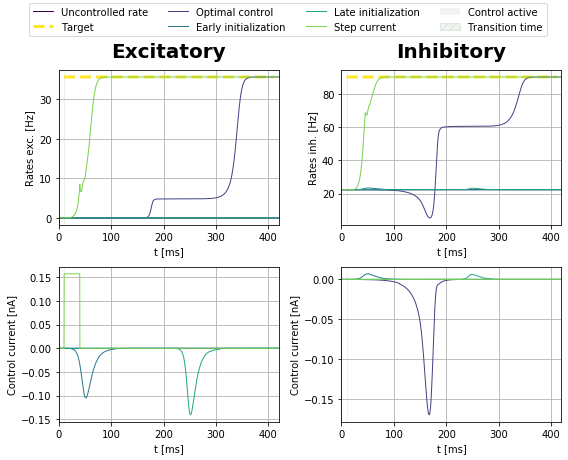

50 0.47500000000000014 0.6000000000000003
DC cost =  1000.0
optimal cost =  5.006400036159537
early init cost =  2.780086874589097
late init cost =  2.7801072411554055


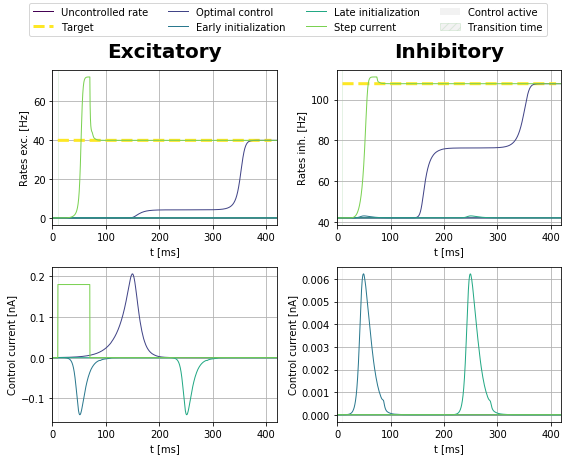

0 0.4500000000000001 0.4750000000000002
1
-------  0 0.4500000000000001 0.4750000000000002
1 0.47500000000000014 0.6000000000000003
1
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
DC cost =  1000.0
optimal cost =  3.552056617539224
early init cost =  2.2901331026304077
late init cost =  3.5212326096033237


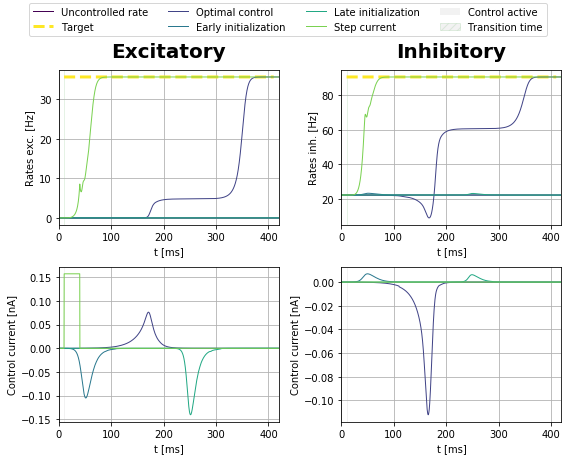

50 0.47500000000000014 0.6000000000000003
DC cost =  1000.0
optimal cost =  11.019413730517254
early init cost =  3.521182167761175
late init cost =  3.5212326096033237


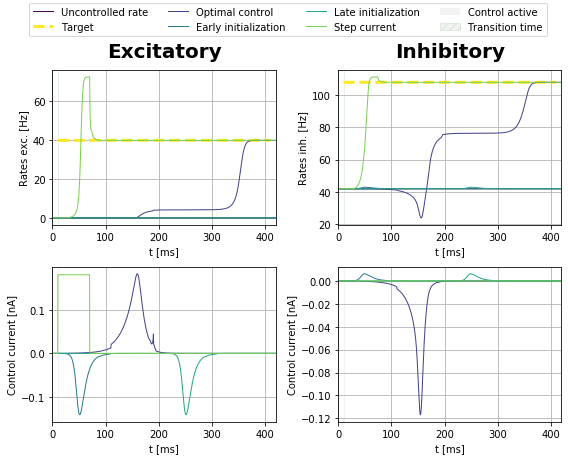

0 0.4500000000000001 0.4750000000000002
1
-------  0 0.4500000000000001 0.4750000000000002
1 0.47500000000000014 0.6000000000000003
1
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
DC cost =  1000.0
optimal cost =  2.1463964678530347
early init cost =  2.291681640712075
late init cost =  2.7801072411554055


AttributeError: 'NoneType' object has no attribute 'copy'

In [10]:
for c_ in range(len(cases_)):
    for i in range(len(ind0)):
        
        print(i, ext_exc[ind0[i]], ext_inh[ind0[i]])
        
        readpath = '..' + os.sep

        control_data = data.read_control(readpath, cases_[c_])
        for j in range(len(ind0)):
            opt_cntrl_0[j] = control_data[2][ind0[j]]
            cost_node_0[j] = control_data[4][ind0[j]]

        readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_-150'
        control_data = data.read_control(readpath, '')
        for j in range(len(ind0)):
            opt_cntrl_min[j] = control_data[2][ind0[j]]
            cost_node_min[j] = control_data[4][ind0[j]]
            
    
        print('1')

        readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_+150'
        control_data = data.read_control(readpath, '')
        for j in range(len(ind0)):
            opt_cntrl_plus[i] = control_data[2][ind0[j]]
            cost_node_plus[i] = control_data[4][ind0[j]]

        print("------- ", i, ext_exc[ind0[i]], ext_inh[ind0[i]])
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.
        aln.params.duration = 3000.
        control0 = aln.getZeroControl()
        control0 = functions.step_control(aln, maxI_ = maxI)
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = -maxI)
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for j in range(len(state_vars)):
            if aln.state[state_vars[j]].size == 1:
                init_state_vars[j] = aln.state[state_vars[j]][0]
            else:
                init_state_vars[j] = aln.state[state_vars[j]][0,-1]

        initVars[i] = init_state_vars

        aln.params.duration = 400.

        target_[i] = aln.getZeroTarget()
        target_[i][:,0,:] = target_rates[0]
        target_[i][:,1,:] = target_rates[1]


    aln.params.duration = dur
    t_sim = aln.params.duration
    t_sim_pre = 10.
    t_sim_post = 10.

    for i in range(len(ind0)):
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.

        print(ind0[i], ext_exc[ind0[i]], ext_inh[ind0[i]])
        setinit(initVars[i], aln)

        print('DC cost = ', mincost[i])
        ind_cost = 2
        if c_ in [1,3]:
            ind_cost = 1
        print('optimal cost = ', cost_node_0[i][0][0,0] + sum(cost_node_0[i][ind_cost][0,:]))
        print('early init cost = ', cost_node_min[i][0][0,0] + sum(cost_node_min[i][ind_cost][0,:]))
        print('late init cost = ', cost_node_plus[i][0][0,0] + sum(cost_node_plus[i][ind_cost][0,:]))
        
        DC_control_shape = np.zeros(( opt_cntrl_0[i].shape ))
        DC_control_shape[:,:,100:-100] = DC_control[c_][i].copy()

        plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_min[i], opt_cntrl_plus[i], DC_control_shape],
                            [cost_node_0[i], cost_node_min[i], cost_node_plus[i]],
                            [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                            target_[i], path_=os.getcwd(), filename_ = str(i) + '_' + task, shading = False,
                            transition_time_ = trans_time, labels_ = ['Optimal control', 'Early initialization',
                            'Late initialization', 'Step current'],
                            precision_variables_ = [0], print_cost_ = False)
        plt.show()